# Home Credit: Development model selection

**15 predeclared candidates · 0 new model fits · holdout unused by this study.**

Can complementary models improve the tuned LightGBM without another fit? This notebook compares hash-verified, aligned development predictions. It is not a final-test or leaderboard result. Weeks 73-91 are excluded from this study. Charts contain interactive Plotly data and static GitHub fallbacks.

In [1]:
import hashlib
import json
from pathlib import Path

import pandas as pd
from IPython.display import display

from home_credit.modeling.selection_report import validate_selection_evidence

parents = [Path.cwd(), *Path.cwd().parents]
candidates = [Path.cwd() / "selection.json"]
candidates += [p / "reports/model_selection/selection.json" for p in parents]
expected_sha256 = "be4b6b7a7468755312128e94aacbaf73a71909350066b5a6ad0a12b141e6c97e"
source = None
for candidate in candidates:
    if not candidate.is_file():
        continue
    digest = hashlib.sha256(candidate.read_bytes()).hexdigest()
    if digest == expected_sha256:
        source = candidate
        break
if source is None:
    raise FileNotFoundError("Matching selection evidence is missing")
result = json.loads(source.read_text())
validate_selection_evidence(result)
print("Scope:", result["scope"])
print("Cases evaluated:", f"{result['rows_evaluated']:,}")
columns = [
    "candidate",
    "mean_fold_stability",
    "worst_fold_stability",
    "oof_auc",
    "oof_pr_auc",
    "oof_brier_score",
    "oof_log_loss",
]
display(pd.DataFrame(result["rows"])[columns].round(6))

Scope: Development-only fixed blends; calibration, nested base-model selection and final holdout remain separate.
Cases evaluated: 727,187


,candidate,mean_fold_stability,worst_fold_stability,oof_auc,oof_pr_auc,oof_brier_score,oof_log_loss
0,tuned_lightgbm_90_lightgbm,0.601899,0.472514,0.849407,0.207859,0.032336,0.126176
1,tuned_lightgbm_75_lightgbm,0.601522,0.462252,0.849430,0.208242,0.032327,0.126154
2,tuned_lightgbm,0.601238,0.479200,0.849286,0.207351,0.032347,0.126222
3,tuned_lightgbm_90_catboost,0.599707,0.467674,0.849600,0.208530,0.032319,0.126113
4,tuned_lightgbm_90_xgboost,0.599143,0.469119,0.849437,0.208037,0.032333,0.126165
5,tuned_lightgbm_50_lightgbm,0.598083,0.442520,0.849077,0.208032,0.032333,0.126230
6,tuned_lightgbm_75_catboost,0.595472,0.445699,0.849647,0.209591,0.032295,0.126070
7,tuned_lightgbm_75_xgboost,0.595205,0.451222,0.849477,0.208628,0.032322,0.126134
8,equal_all_four,0.587509,0.398523,0.849186,0.209928,0.032293,0.126163
9,tuned_lightgbm_50_xgboost,0.586233,0.420128,0.849091,0.208539,0.032329,0.126217


## Stability, time and reliability

Selection maximizes the mean of five official fold stability scores. ROC AUC and average precision describe ranking; raw Brier and clipped log loss describe probabilities. Weekly hover information includes fold, case count and default rate: a noisy, low-support week must not be mistaken for a reliable trend. The offline HTML preserves interactivity.

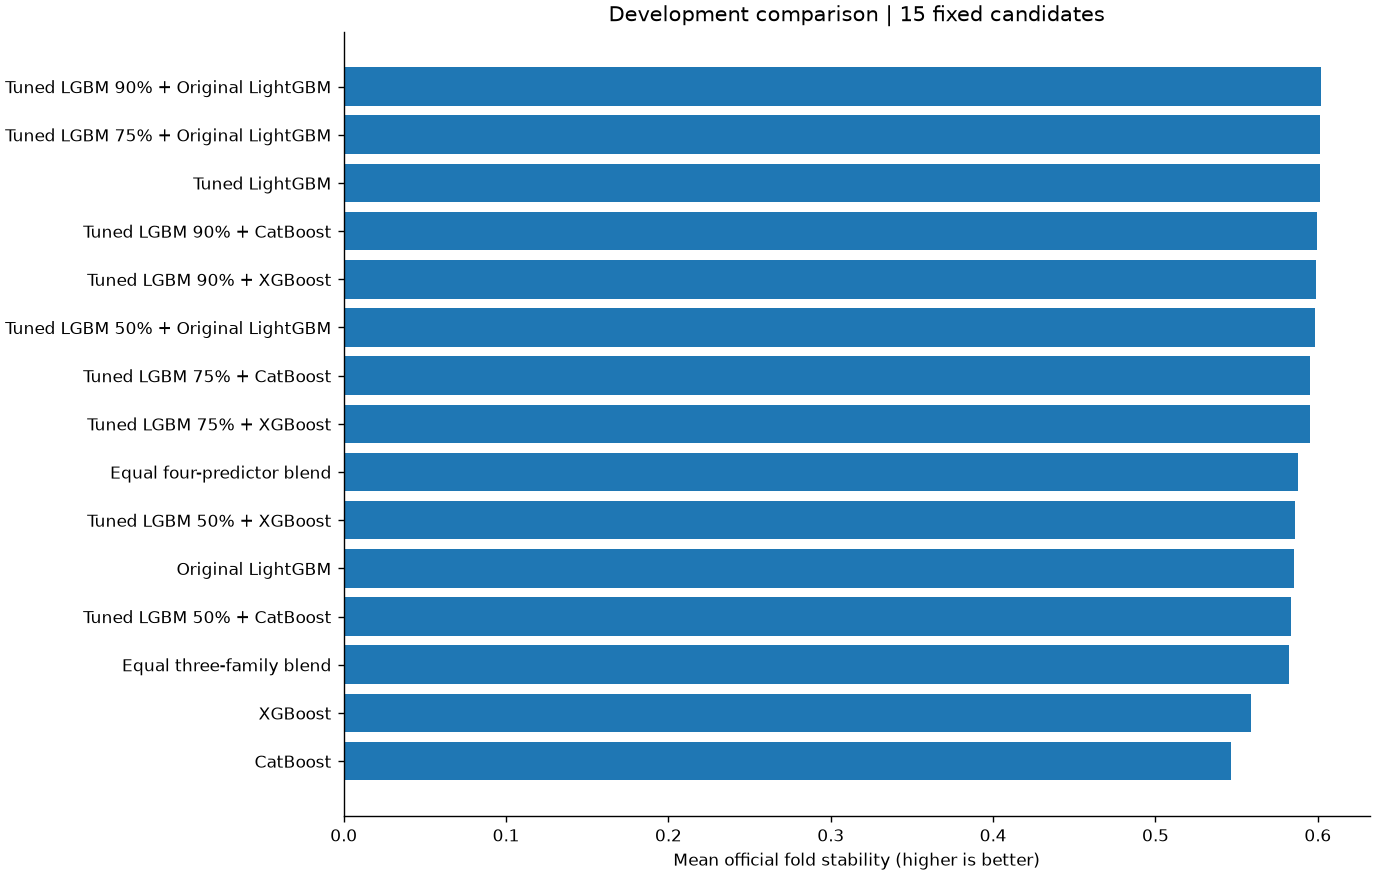

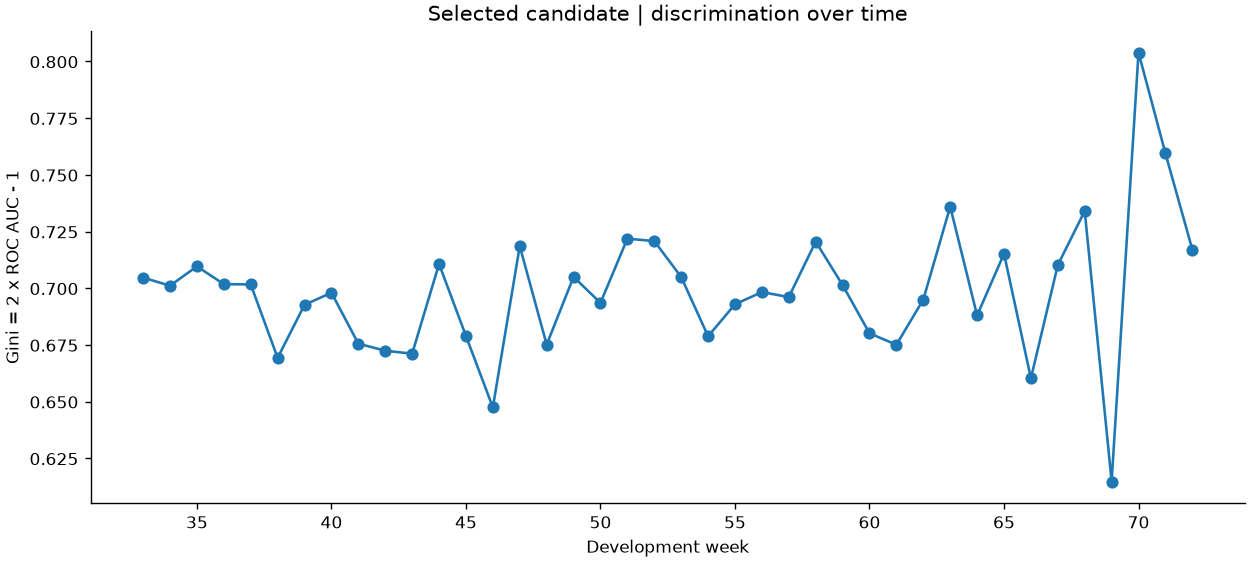

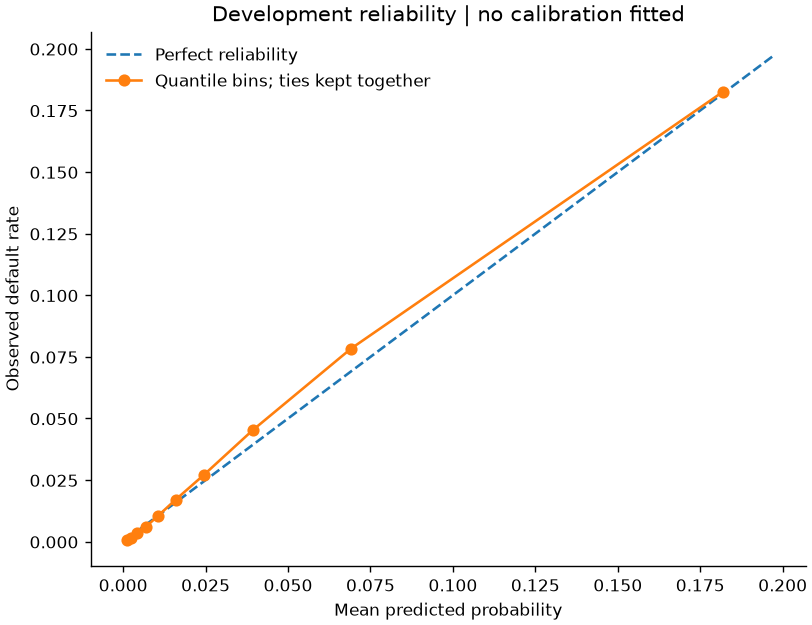

In [2]:
import base64
from io import BytesIO

import matplotlib.pyplot as plt

from home_credit.modeling.selection_report import (
    selection_figures,
    selection_plotly_figures,
)

interactive = selection_plotly_figures(result)
for name, figure in selection_figures(result).items():
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=125)
    payload = json.loads(interactive[name].to_json())
    display(
        {
            "image/png": base64.b64encode(buffer.getvalue()).decode("ascii"),
            "application/vnd.plotly.v1+json": payload,
        },
        raw=True,
    )
    plt.close(figure)

## Does the weight choice transfer to the next fold?

This diagnostic chooses weights using earlier folds and observes the next fold. **It is not fully nested validation:** base-model tuning already used all development folds. Correlation indicates how similar the predictors are; only measured blend performance justifies complexity.

In [3]:
display(pd.DataFrame(result["prequential_weight_choices"]).round(6))
display(pd.DataFrame(result["diagnostics"]["prediction_correlations"]).round(6))
selected = result["selected_candidate"]
winner = next(r for r in result["rows"] if r["candidate"] == selected)
folds = pd.DataFrame(result["folds"])
scores = folds.pivot(index="fold", columns="candidate", values="stability_score")
comparison = scores[[selected, "tuned_lightgbm"]].copy()
if selected == "tuned_lightgbm":
    print("No blend improved the declared objective; retain the simpler incumbent.")
else:
    delta = comparison.iloc[:, 0] - comparison.iloc[:, 1]
    display(delta.rename("Selected minus tuned LightGBM").to_frame().round(6))
    print("Folds improved:", int((delta > 0).sum()), "of", len(delta))
print("Selected development candidate:", selected)
print("Mean stability gain:", f"{winner['delta_vs_tuned_lightgbm']:+.6f}")
print(json.dumps(result["selected_weights"], indent=2, sort_keys=True))

,auc,brier_score,candidate,fold,log_loss,mean_gini,pr_auc,residual_std,selected_using_folds,stability_score,temporal_slope
0,0.841846,0.032430,tuned_lightgbm,2,0.127362,0.680865,0.191645,0.021070,[1],0.670330,0.001478
1,0.852478,0.032380,tuned_lightgbm,3,0.125873,0.701810,0.208511,0.012329,"[1, 2]",0.487354,-0.002367
2,0.849981,0.039158,tuned_lightgbm,4,0.147519,0.698636,0.253749,0.018753,"[1, 2, 3]",0.680313,-0.000102
3,0.864525,0.020162,tuned_lightgbm_90_lightgbm,5,0.084819,0.714400,0.173465,0.050776,"[1, 2, 3, 4]",0.689011,0.007981


,first,pearson_prediction_correlation,second
0,tuned_lightgbm,0.971202,lightgbm
1,tuned_lightgbm,0.965236,xgboost
2,tuned_lightgbm,0.930606,catboost
3,lightgbm,0.971377,xgboost
4,lightgbm,0.933562,catboost
5,xgboost,0.926413,catboost


,Selected minus tuned LightGBM
fold,
1,-0.006686
2,0.000393
3,0.004212
4,0.005367
5,0.000020


Folds improved: 4 of 5
Selected development candidate: tuned_lightgbm_90_lightgbm
Mean stability gain: +0.000661
{
  "lightgbm": 0.09999999999999998,
  "tuned_lightgbm": 0.9
}


## Decision boundary and owner-controlled release

Development improvement is not a claim of state-of-the-art or future performance. Freeze model, ensemble and calibration choices before evaluating the locked holdout once. Final refit, train/test feature parity and competition-compatible inference still need their own tested stage.

The submission notebook will require an explicit owner action to generate predictions, validate `case_id,score`, preserve sample order, save durably and show a download link. **This review creates no submission CSV and never uploads to Kaggle.**

In [4]:
import os

from IPython.display import FileLink

relative_evidence = os.path.relpath(source)
display(FileLink(relative_evidence, result_html_prefix="Aggregate evidence: "))
display(
    FileLink(
        os.path.relpath(source.parent / "report.html"),
        result_html_prefix="Interactive offline review: ",
    )
)

/home/runner/work/home-credit-model-stability/home-credit-model-stability/artifacts/model_selection_review/be4b6b7a7468755312128e94aacbaf73a71909350066b5a6ad0a12b141e6c97e/05548211797cf38b570dcaa2825785f8cc3f9555b737fff42e8634f0a47728c4/selection.json

/home/runner/work/home-credit-model-stability/home-credit-model-stability/artifacts/model_selection_review/be4b6b7a7468755312128e94aacbaf73a71909350066b5a6ad0a12b141e6c97e/05548211797cf38b570dcaa2825785f8cc3f9555b737fff42e8634f0a47728c4/report.html